In [ ]:
'''
Explore data

Fill na and remove NDN as it has obvious mistake in values

Cluster used data is stored in cluster_used_data.parquet

'''


In [59]:
import pandas as pd


In [ ]:
import matplotlib.pyplot as plt


In [ ]:
import numpy as np


In [ ]:
import seaborn as sns


In [60]:
ratio_df=pd.read_parquet('ratio_data.parquet')


In [61]:
df=ratio_df.copy()
df=df[df['report_date']>pd.Timestamp("2020-01-01")]
df.sort_values(by=['symbol','report_date'], inplace=True)


In [62]:
print("2020-01-01 to 2024-12-31 data shape:")
print(df.shape)


2020-01-01 to 2024-12-31 data shape:
(1147, 10)


In [63]:
ratio_features=['DE',
                 'NCOS',
                 'PNNIS',
                 'NDN',
                 'STA',
                 'ICSNW',
                 'NITN',
                 'CASH_PER_SHARE']


In [64]:
missing_num=df.groupby('symbol')[ratio_features].agg(lambda x:x.isnull().sum() )


In [65]:
print('Feature missing number for every stocks')
print(missing_num)


Feature missing number for every stocks
        DE  NCOS  PNNIS  NDN  STA  ICSNW  NITN  CASH_PER_SHARE
symbol                                                        
000063   0     0      0    0    0      0     0               0
000333   0     0      0    0    0      0     0               0
000617   0     0      0    0    0      0     0               0
000725   0     0      0    0    0      0     0               0
000792   0     0      0    0    0      0     0               0
000938   0     0      0    0    0      0     0               0
002027   0     0      0    0    0      0     0               0
002230   0     0      0    0    0      0     0               0
002371   0     0      0    0    0      0     0               0
002475   0     0      0    0    0      0     0               0
002594   0     0      0    0    0      0     0               0
002714   0     0      0    0    0      0     0               0
300015   0     0      0    0    0      0     0               0
300124   0     

In [66]:
row_with_missing=missing_num.index[(missing_num !=0).any(axis=1)].tolist()


In [67]:
print('\n Stocks which have missing values:')
print(f'\n {row_with_missing}')
print("\n There are 3 stocks which have missing values")



 Stocks which have missing values:

 ['600941', '605499', '688981']

 There are 3 stocks which have missing values


In [68]:
print('Three stocks missing condition:')
print(missing_num.loc[row_with_missing])


Three stocks missing condition:
        DE  NCOS  PNNIS  NDN  STA  ICSNW  NITN  CASH_PER_SHARE
symbol                                                        
600941   2     0      0    6    2      2     0               6
605499   2     0      1    2    2      2     0               2
688981   0     0      0    2    0      0     0               2


In [69]:
rows_with_nan=df[df.isnull().any(axis=1)]
print('rows with nan value:')
print(rows_with_nan)


rows with nan value:
      symbol report_date        DE      NCOS     PNNIS  NDN       STA  \
3347  600941  2020-09-30       NaN  0.446619  0.135742  NaN       NaN   
3346  600941  2020-12-31  0.514653  0.400693  0.133030  NaN  0.687328   
3345  600941  2021-03-31       NaN  0.384379  0.113391  NaN       NaN   
3344  600941  2021-06-30  0.539549  0.364294  0.124881  NaN  0.386945   
3343  600941  2021-09-30  0.543953  0.384064  0.124505  NaN  0.565491   
3342  600941  2021-12-31  0.537055  0.371071  0.126634  NaN  0.721927   
4056  605499  2020-03-31       NaN -0.044922  0.173193  NaN       NaN   
4054  605499  2020-09-30       NaN  0.216424       NaN  NaN       NaN   
4081  688981  2020-03-31  0.735925  0.239316  0.022274  NaN  0.088431   
4080  688981  2020-06-30  0.547182  0.235060  0.041174  NaN  0.141055   

         ICSNW      NITN  CASH_PER_SHARE  
3347       NaN  0.998164             NaN  
3346  0.091435  0.997253             NaN  
3345       NaN  0.998837             NaN  
334

In [70]:
# fill nan
# first forward fill / second backward fill
for col in ratio_features:
    df[col] = df.groupby('symbol')[col].transform(lambda x: x.ffill().bfill())

print("填充后数据缺失统计：")
print(df[ratio_features].isnull().sum())


填充后数据缺失统计：
DE                0
NCOS              0
PNNIS             0
NDN               0
STA               0
ICSNW             0
NITN              0
CASH_PER_SHARE    0
dtype: int64


In [71]:
print('Data information:')
print(df.info())
print('\n Data statistic description:')
print(df.describe())


Data information:
<class 'pandas.core.frame.DataFrame'>
Index: 1147 entries, 22 to 4060
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   symbol          1147 non-null   object        
 1   report_date     1147 non-null   datetime64[ns]
 2   DE              1147 non-null   float64       
 3   NCOS            1147 non-null   float64       
 4   PNNIS           1147 non-null   float64       
 5   NDN             1147 non-null   float64       
 6   STA             1147 non-null   float64       
 7   ICSNW           1147 non-null   float64       
 8   NITN            1147 non-null   float64       
 9   CASH_PER_SHARE  1147 non-null   float64       
dtypes: datetime64[ns](1), float64(8), object(1)
memory usage: 98.6+ KB
None

 Data statistic description:
                         report_date           DE         NCOS        PNNIS  \
count                           1147  1147.000000  1147.000000  1147.

### How to identify the corrctness of data

## DISTRIBUTION

### 1.DE

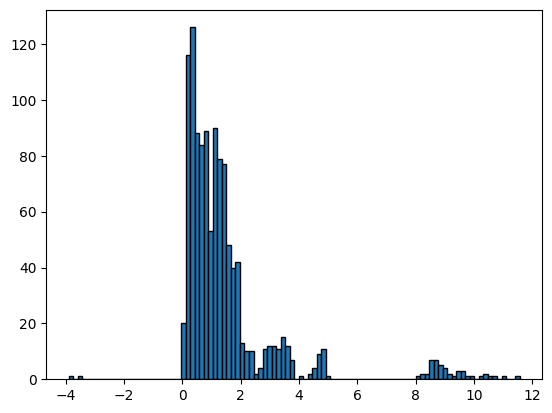

In [ ]:
#de distribution
fig,ax=plt.subplots()
ax.hist(df['DE'],bins=100,edgecolor='black')
plt.show()


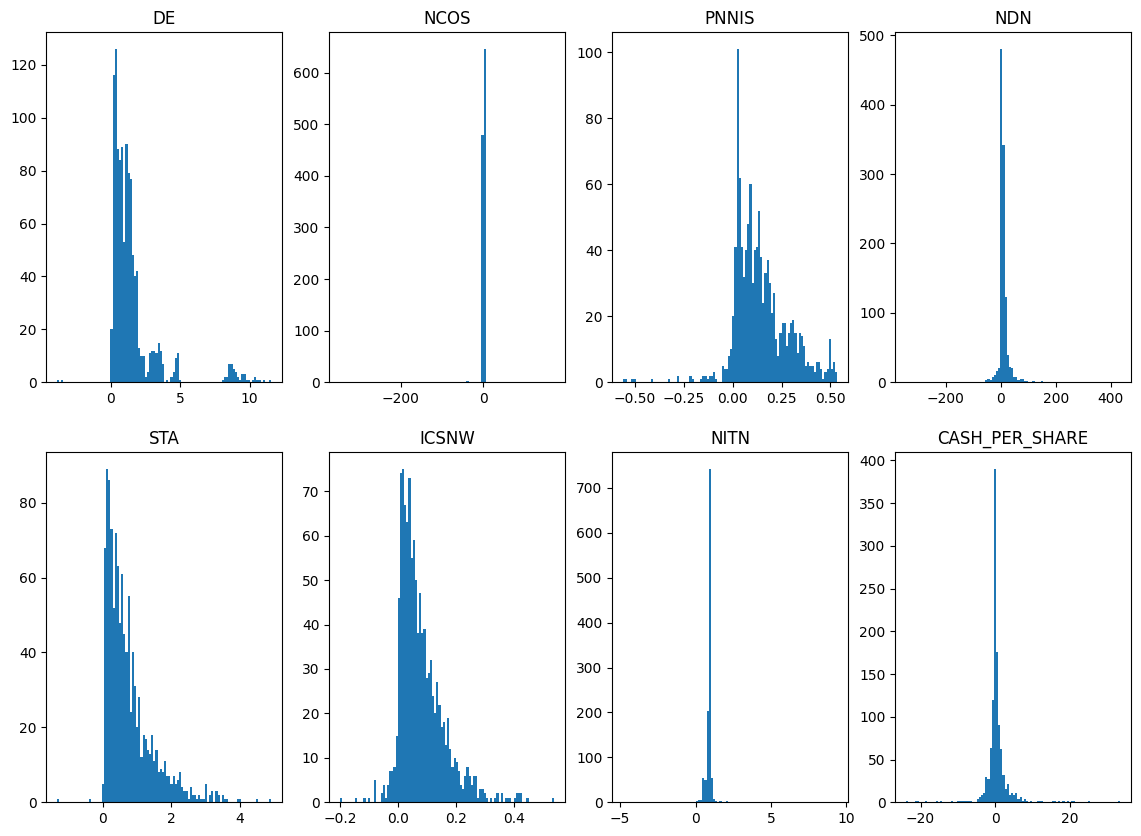

In [ ]:
fig,axs=plt.subplots(2,4,figsize=(14,10))
d=len(ratio_features)
for i in range(d):
    x=i//4
    y=i%4
    axs[x,y].hist(df[ratio_features[i]],bins=100)#,edgecolor='black')
    axs[x,y].set_title(ratio_features[i])
plt.show()


1. DE
- debt to equity is mainly between 0-2 
- there is a few locating around 10
2. NCOS
- has extreme number
- mainly around 0
3. PNNIS 
- mainly between 0-0.5
4. NDN
- has wierld number((net inc-divid/net inc)>1?)
5. STA
- mainly between 0-1
6. ICSNW
- mainly between -0.1-0.2
7. NITN
- mainly between 0-1
8. CASH_PER_SHARE
- around 0


### NCOS

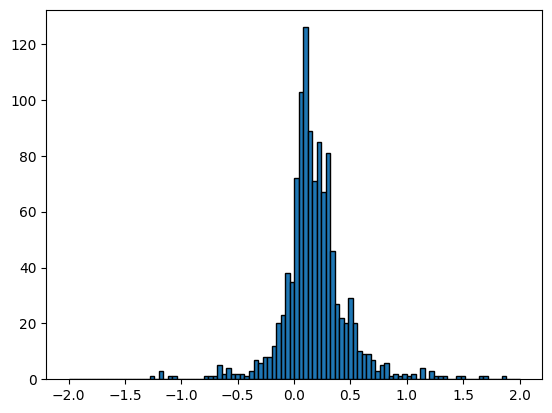

In [ ]:
#ncos distribtion
fig,ax=plt.subplots()
ax.hist(df['NCOS'],bins=100,range=(-2,2),edgecolor='black')
plt.show()


- NCOS:mainly between 0-0.5

### NDN

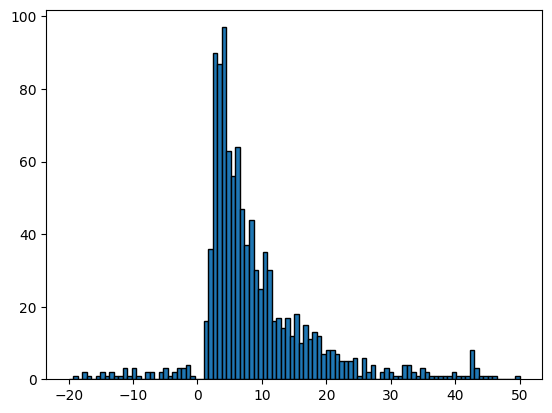

In [ ]:
#ndn distribtion
fig,ax=plt.subplots()
ax.hist(df['NDN'],bins=100,range=(-20,50),edgecolor='black')
plt.show()


- ndn means (net inc-divid)/net inc
- but the distribution is mainly around 5. so the feature is not reliable.


### NITN

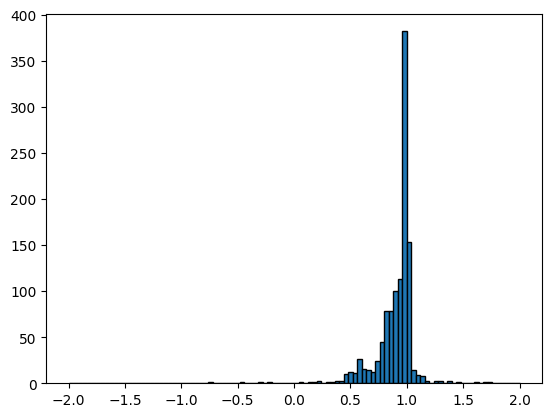

In [ ]:
#nitn distribtion
fig,ax=plt.subplots()
ax.hist(df['NITN'],bins=100,range=(-2,2),edgecolor='black')
plt.show()


- NITN=(Net Inc -Inc Taxes)/Net Inc
- THERE are nitn>1, the feature is not reliable too

### CASH PER SHARE

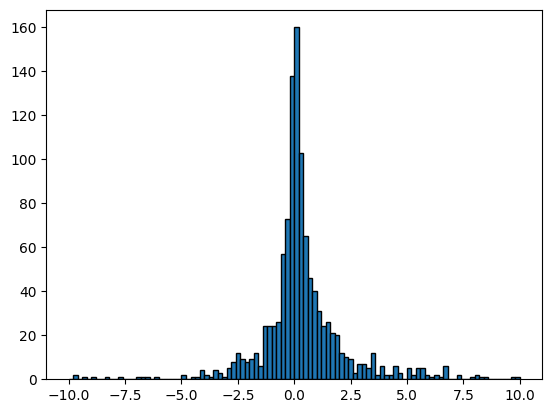

In [ ]:
#nitn distribtion
fig,ax=plt.subplots()
ax.hist(df['CASH_PER_SHARE'],bins=100,range=(-10,10),edgecolor='black')
plt.show()


- very typical normal distribution

## CORRLARATE

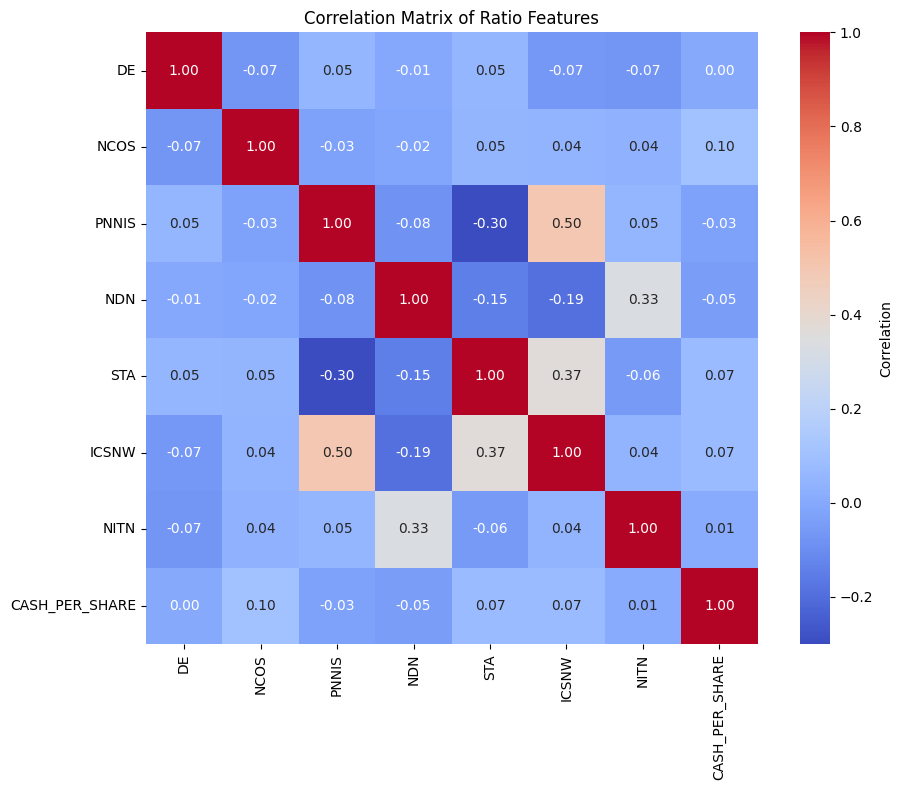

In [ ]:
# calculate corr
corr_matrix = df[ratio_features].corr()

# headmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, ax=ax, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix of Ratio Features')
plt.tight_layout()
plt.show()


1. PNNIS - ICSNW
- CORR:0.5
- both have numerator = income common
- PNNIS'denominator = total income
- ICSNW'denominator = net worth 
2. STA - ICSNW
- CORR:0.37
- both have denominator = net worth
- STA's numerator = totaL income
- ICSNW'numerator = income common
3. PNNIS -STA
- CORR:-0.30
- PNNIS'denominator and STA'numerator is same = total income


In [ ]:
# remove NDN
df.drop(labels='NDN',axis=1,inplace=True)


In [ ]:
'''fill na and remove NDN as it has obvious mistake in values'''
df.to_parquet('cluster_used_data.parquet')
print("\n Cluster used data is stored in cluster_used_data.parquet")



 Cluster used data is stored in cluster_used_data.parquet
